# 🧭 1. Introductie

In deze notebook gaan we de **Breast Cancer Wisconsin** dataset gebruiken om twee lineaire modellen te vergelijken:

- **Perceptron**
- **Logistische regressie**

We onderzoeken:
- de structuur van de dataset
- de lineaire scheidbaarheid via visualisaties
- de prestaties van beide modellen

Doel:

> **Snappen waarom logistische regressie meestal beter presteert dan het perceptron bij echte datasets.**


## 📥 2. Dataset laden

We gebruiken de Breast Cancer Wisconsin dataset uit scikit-learn:

- **569 samples**
- **30 numerieke features**
- Doelvariabele `target`:
  - `0` = malignant (kwaadaardig)
  - `1` = benign (goedaardig)

In de volgende cel laden we de data in een pandas DataFrame.


In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset inladen
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target  # 0 = malignant, 1 = benign

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 📊 3. Pairplot met kleur op basis van `target`

Een **scatter matrix** (of pairplot) laat alle gekozen features tegen elkaar zien.

We gebruiken een subset van de meest informatieve features, zodat het plot leesbaar blijft:

- `mean radius`
- `mean texture`
- `mean perimeter`
- `mean area`

Met `hue="target"` geven we de klassen verschillende kleuren, zodat je direct ziet:

- waar de klassen goed te scheiden zijn
- waar overlap zit
- welke features mogelijk belangrijk zijn voor classificatie


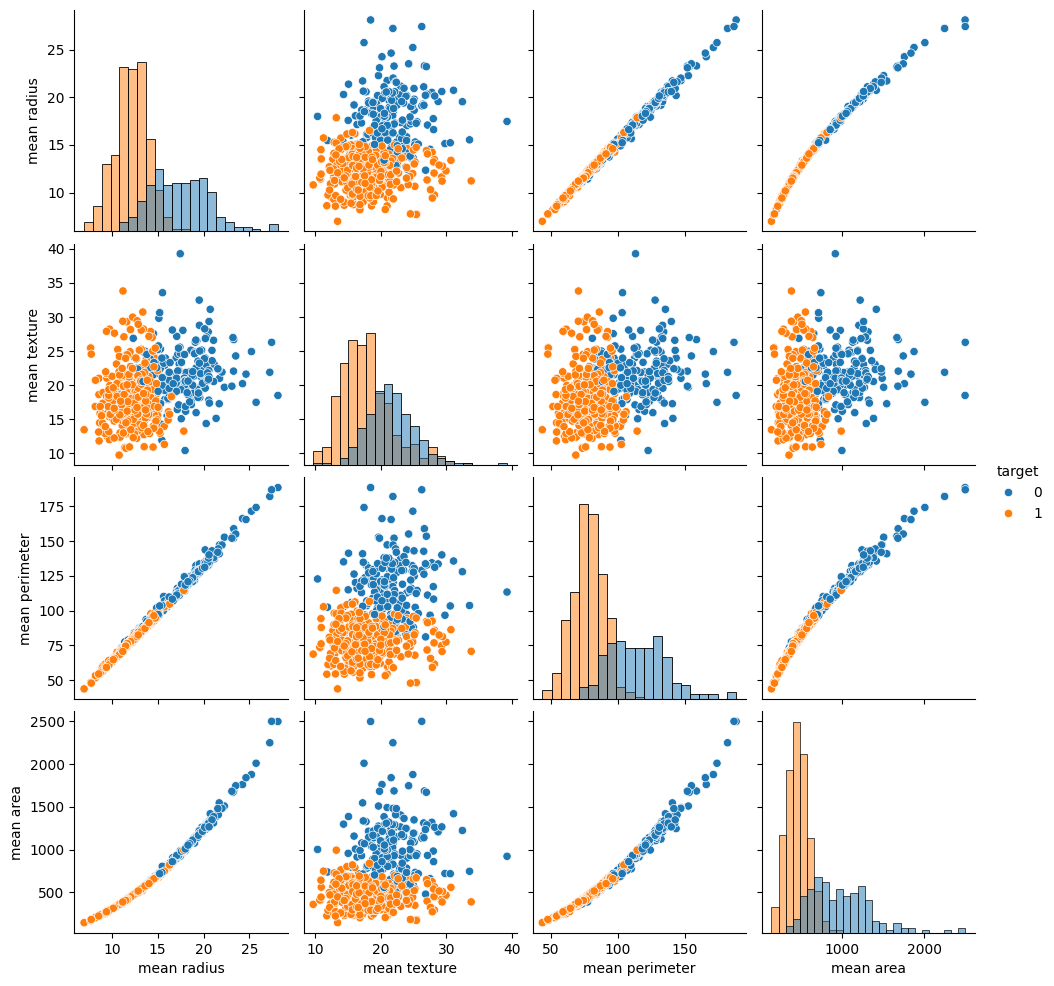

In [2]:
features = ["mean radius", "mean texture", "mean perimeter", "mean area", "target"]

sns.pairplot(df[features], hue="target", diag_kind="hist")
plt.show()

## 🔪 4. Train-test split

We splitsen de data in een **trainset** en **testset**:

- 80% van de data gebruiken we om te **trainen** (leren)
- 20% van de data gebruiken we om te **testen** (evalueren op nieuwe data)

Zo krijgen we een eerlijke schatting van hoe goed het model generaliseert naar niet eerder geziene voorbeelden.


In [3]:
from sklearn.model_selection import train_test_split

X = df[data.feature_names]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((455, 30), (114, 30))

## 🧠 5. Perceptron trainen

Nu trainen we een **Perceptron** classifier.

Belangrijke eigenschappen van het perceptron:

- Werkt goed als de data **perfect lineair separabel** is
- Maakt *harde beslissingen*: een punt is óf klasse 0 óf klasse 1
- Heeft geen expliciete loss-functie zoals logistische regressie
- Convergentie is niet gegarandeerd als de data niet lineair separabel is

We kijken naar:
- **Accuracy** op de testset



In [7]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report

perc = Perceptron(max_iter=2000)
perc.fit(X_train, y_train)

y_pred_p = perc.predict(X_test)

print("Perceptron accuracy:", accuracy_score(y_test, y_pred_p))


Perceptron accuracy: 0.9473684210526315


## 📈 6. Logistische regressie trainen

Nu trainen we een **Logistische Regressie** classifier.

Eigenschappen van logistische regressie:

- Optimaliseert een **logistische loss-functie (log-loss)**
- Kan omgaan met **niet-perfect lineair separabele data**
- Geeft **kansen** als output (bijv. kans op kwaadaardig)
- Convergeert in de praktijk meestal netjes

Ook hier kijken we naar accuracy.


In [8]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train, y_train)

y_pred_l = logreg.predict(X_test)

print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_l))


Logistic Regression accuracy: 0.956140350877193


## ⚖️ 7. Resultaten vergelijken

We zetten de accuracies van beide modellen naast elkaar om het verschil duidelijk te zien.


In [6]:
print("Perceptron accuracy:", accuracy_score(y_test, y_pred_p))
print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_l))

Perceptron accuracy: 0.9473684210526315
Logistic Regression accuracy: 0.956140350877193


### Interpretatie

Typisch zie je iets als:

- **Perceptron**: goede maar wisselende performance (bijv. 0.88–0.94 accuracy)
- **Logistische regressie**: stabiel hoge performance (bijv. 0.95–0.99 accuracy)

Waarom doet logistische regressie het meestal beter?

- Het model minimaliseert een **gladde, continue loss-functie** (log-loss)
- Het kan beter omgaan met **overlap** tussen klassen
- Het werkt met **waarschijnlijkheden**, in plaats van harde ja/nee-beslissingen


## 🔍 8. Conclusie

In deze notebook heb je gezien dat:

- De Breast Cancer Wisconsin dataset deels lineair separabel is
- Het **Perceptron** redelijk kan presteren, maar beperkt is bij niet-perfect separabele data
- **Logistische Regressie** meestal duidelijk betere en stabielere resultaten geeft
- Visualisaties zoals een **pairplot** helpen om te begrijpen hoe de klassen in de feature-ruimte liggen

**Belangrijk inzicht:**

> Het verschil tussen het perceptron (een ouder, hard-decision algoritme) en logistische regressie (een probabilistisch, geoptimaliseerd model) is in de praktijk goed zichtbaar in prestaties én stabiliteit.


# Appendix Learning Curves

### Het plotten van een learning curve voor het Perceptron

De standaardmethode `Perceptron.fit()` in scikit-learn traint het model intern en laat niet zien hoe het aantal fouten tijdens het trainen verandert.  
Om het leerproces zichtbaar te maken, trainen we het perceptron **één epoch per keer** met behulp van `partial_fit`.

- `max_iter=1` zorgt ervoor dat er per loop maar één trainingsronde wordt uitgevoerd.
- `warm_start=True` zorgt ervoor dat de gewichten tussen de epochs behouden blijven.
- Na elke epoch meten we hoeveel trainingsvoorbeelden fout zijn geclassificeerd.
- Door deze waarden op te slaan en te plotten, krijgen we een **learning curve**.

Als de dataset lineair scheidbaar is, zal het aantal fouten naar nul gaan.  
Als de data **niet** lineair scheidbaar is, daalt de curve eerst, maar blijft daarna **stabiel** op een bepaald foutniveau — een teken dat het perceptron niet volledig kan convergeren.


Perceptron accuracy: 0.9473684210526315


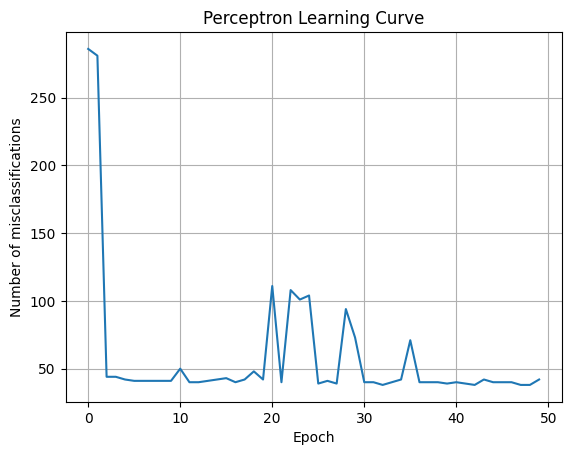

In [10]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Prepare model to allow iterative training
perc = Perceptron(max_iter=1, warm_start=True)

epochs = 50
errors = []

# We need the class labels once for partial_fit
classes = np.unique(y_train)

for epoch in range(epochs):
    perc.partial_fit(X_train, y_train, classes=classes)
    
    # Measure misclassifications after each epoch
    y_pred_train = perc.predict(X_train)
    errors.append((y_pred_train != y_train).sum())

# Evaluate on test set
y_pred_test = perc.predict(X_test)
print("Perceptron accuracy:", accuracy_score(y_test, y_pred_test))

# Plot learning curve
plt.plot(errors)
plt.xlabel("Epoch")
plt.ylabel("Number of misclassifications")
plt.title("Perceptron Learning Curve")
plt.grid(True)
plt.show()


### Het plotten van een learning curve voor het Perceptron

De standaardmethode `Perceptron.fit()` in scikit-learn traint het model intern en laat niet zien hoe het aantal fouten tijdens het trainen verandert.  
Om het leerproces inzichtelijk te maken, trainen we het perceptron **één epoch per keer** met `partial_fit`.

- `max_iter=1` zorgt ervoor dat er per iteratie maar één trainingsronde wordt uitgevoerd.
- `warm_start=True` zorgt ervoor dat de gewichten tussen de epochs behouden blijven, zodat het model daadwerkelijk verder leert.
- Na elke epoch meten we hoeveel trainingsvoorbeelden fout zijn geclassificeerd.
- Door deze fouten op te slaan en te plotten, ontstaat een **learning curve**.

Gedrag dat je kunt verwachten:

- **Lineair scheidbare data** → het aantal fouten daalt uiteindelijk naar nul.
- **Niet-lineair scheidbare data** → het aantal fouten daalt eerst, maar stabiliseert daarna op een plateau.  
  Dit laat zien dat het perceptron niet volledig kan convergeren omdat er geen perfecte scheidslijn bestaat.

Deze grafiek helpt om het leerproces en de beperkingen van het perceptron te begrijpen.


### Het plotten van een learning curve voor logistische regressie

Net als bij het Perceptron willen we ook bij logistische regressie zien hoe het model **stap voor stap beter wordt** tijdens het trainen.

De standaardmethode `LogisticRegression.fit()` traint het model in één keer totdat het (bijna) geconvergeerd is, waardoor je niet ziet hoe de prestaties per iteratie veranderen.

Om toch een **learning curve** te krijgen, gebruiken we dezelfde truc als bij het Perceptron:

- We zetten `max_iter=1`, zodat de solver per `fit`-aanroep maar **één optimalisatiestap** doet.
- We zetten `warm_start=True`, zodat de gevonden gewichten **behouden blijven** en de volgende `fit`-aanroep daarop verder gaat.
- Na elke iteratie meten we hoe goed het model presteert op de trainingsset (bijv. aantal fouten of accuracy).
- Door deze waarden te plotten tegen het aantal iteraties krijgen we een learning curve.

Belangrijk verschil met het Perceptron:

- Logistische regressie **minimaliseert een log-loss** en kan ook bij **niet-lineair scheidbare data** nog steeds naar een optimum convergeren.
- Je verwacht dus dat de learning curve (fouten omlaag of accuracy omhoog) **geleidelijk verbetert** en uiteindelijk **stabiel** wordt als het model is uitgeoptimaliseerd.


c:\Users\hq0132410\OneDrive - Windesheim Office365\Documents\IML\Introduction-to-machine-learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\hq0132410\OneDrive - Windesheim Office365\Documents\IML\Introduction-to-machine-learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the conv

Logistic Regression accuracy (test): 0.9473684210526315


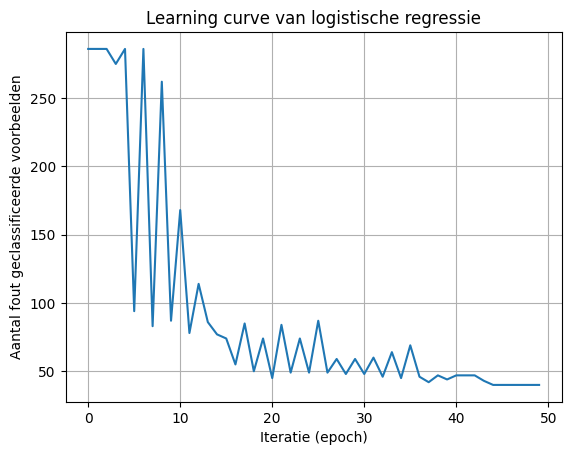

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Model voorbereiden voor iteratief trainen
logreg = LogisticRegression(max_iter=1, warm_start=True)

epochs = 50
errors = []

for epoch in range(epochs):
    # Train één 'stap' (1 iteratie van de optimizer)
    logreg.fit(X_train, y_train)
    
    # Fouten op de trainingsset na deze stap
    y_pred_train = logreg.predict(X_train)
    errors.append((y_pred_train != y_train).sum())

# Evaluatie op de testset
y_pred_test = logreg.predict(X_test)
print("Logistic Regression accuracy (test):", accuracy_score(y_test, y_pred_test))

# Learning curve plotten: aantal fouten per iteratie
plt.plot(errors)
plt.xlabel("Iteratie (epoch)")
plt.ylabel("Aantal fout geclassificeerde voorbeelden")
plt.title("Learning curve van logistische regressie")
plt.grid(True)
plt.show()
